0. Setup Awal

In [30]:
import os
import time
import tracemalloc
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = 'outputKmeansManhattan'
os.makedirs(OUTPUT_DIR, exist_ok=True)

1. Data Understanding

1.1 Load Dataset

In [31]:
df = pd.read_csv('burnout_dataset1.csv')

print(f'Jumlah data awal: {len(df)}')

# df = df.sample(
#     n=5000,
#     random_state=42
# ).reset_index(drop=True)
# print(f'Jumlah data setelah sampling: {len(df)}')

Jumlah data awal: 50000


1.2 Data Preview

In [32]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [33]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                               str
Country                              str
Occupation                           str
Education_Level                      str
Employment_Status                    str
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                          str
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                        str
Stress_Level                         str
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                   str
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

Age                         250
Monthly_Income_USD         1450
Job_Satisfaction            500
Work_Life_Balance           650
Sleep_Hours                 950
Anxiety_Score               800
Depression_Score            850
Mood_Score                  900
Physical_Activity_Hours    1100
Meditation_Minutes         1200
Screen_Time_Hours           850
Social_Media_Hours          600
Gaming_Hours                750
Therapy_Attendance          400
Life_Satisfaction           700
Productivity_Score          950
dtype: int64

1.4 Identifikasi Kolom yang Digunakan

In [34]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(include='number').columns

# Kolom kategorikal yang akan di-encoding
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print('Kolom Numerik:')
print(numeric_columns.tolist())

print('\nKolom Kategorikal yang akan di-encoding:')
print(categorical_columns)

Kolom Numerik:
['Person_ID', 'Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Kolom Kategorikal yang akan di-encoding:
Index(['Gender', 'Country', 'Occupation', 'Education_Level',
       'Employment_Status', 'Remote_Work', 'Sleep_Quality', 'Stress_Level',
       'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet',
       'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance',
       'Support_System', 'Mental_Health_Status', 'AI_Wellness_Recommendation',
       'Burnout_Risk'],
      dtype='str')


1.5 Statistik Deskriptif

In [35]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Person_ID,50000.0,25000.500000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
Age,49750.0,41.448181,13.871634,18.0,29.00,41.0,53.00,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.00,6231.0,9134.00,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.00,45.0,58.00,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.00,6.0,8.00,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.00,6.0,8.00,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.50,7.0,8.50,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.00,39.0,59.00,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.00,39.0,60.00,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.00,61.0,80.00,100.0


1.6 Visualisasi Distribusi Data

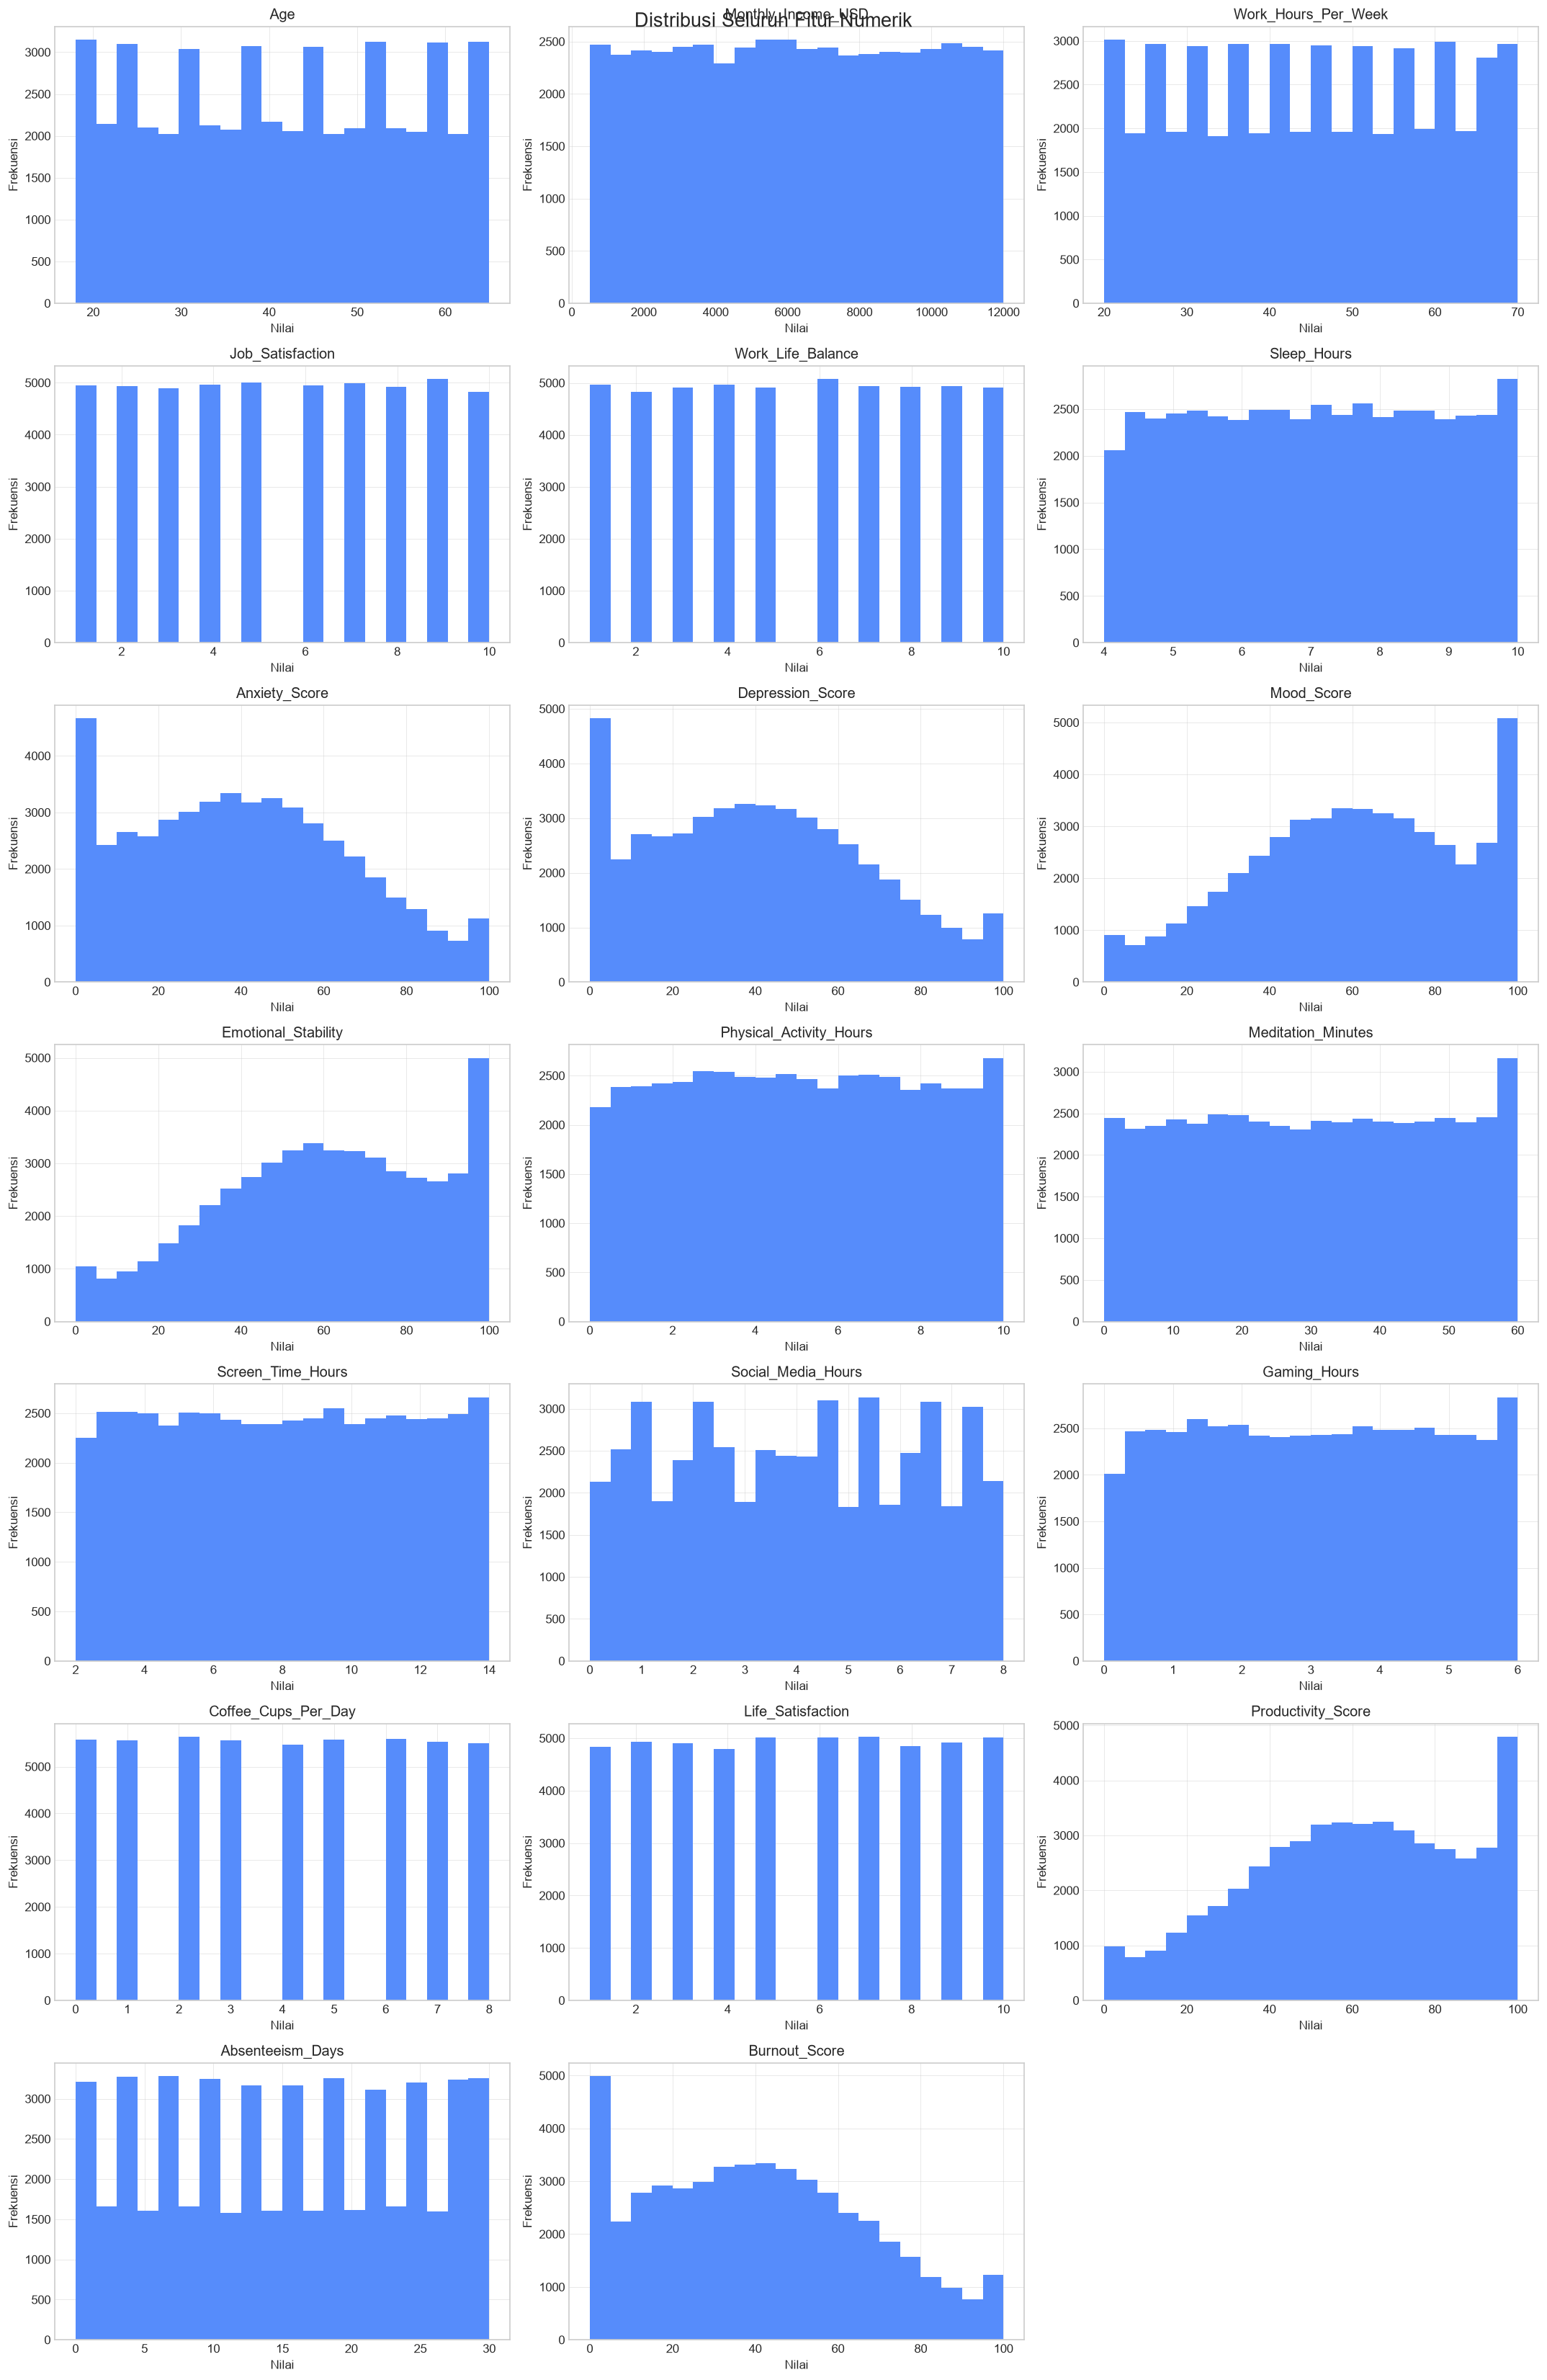

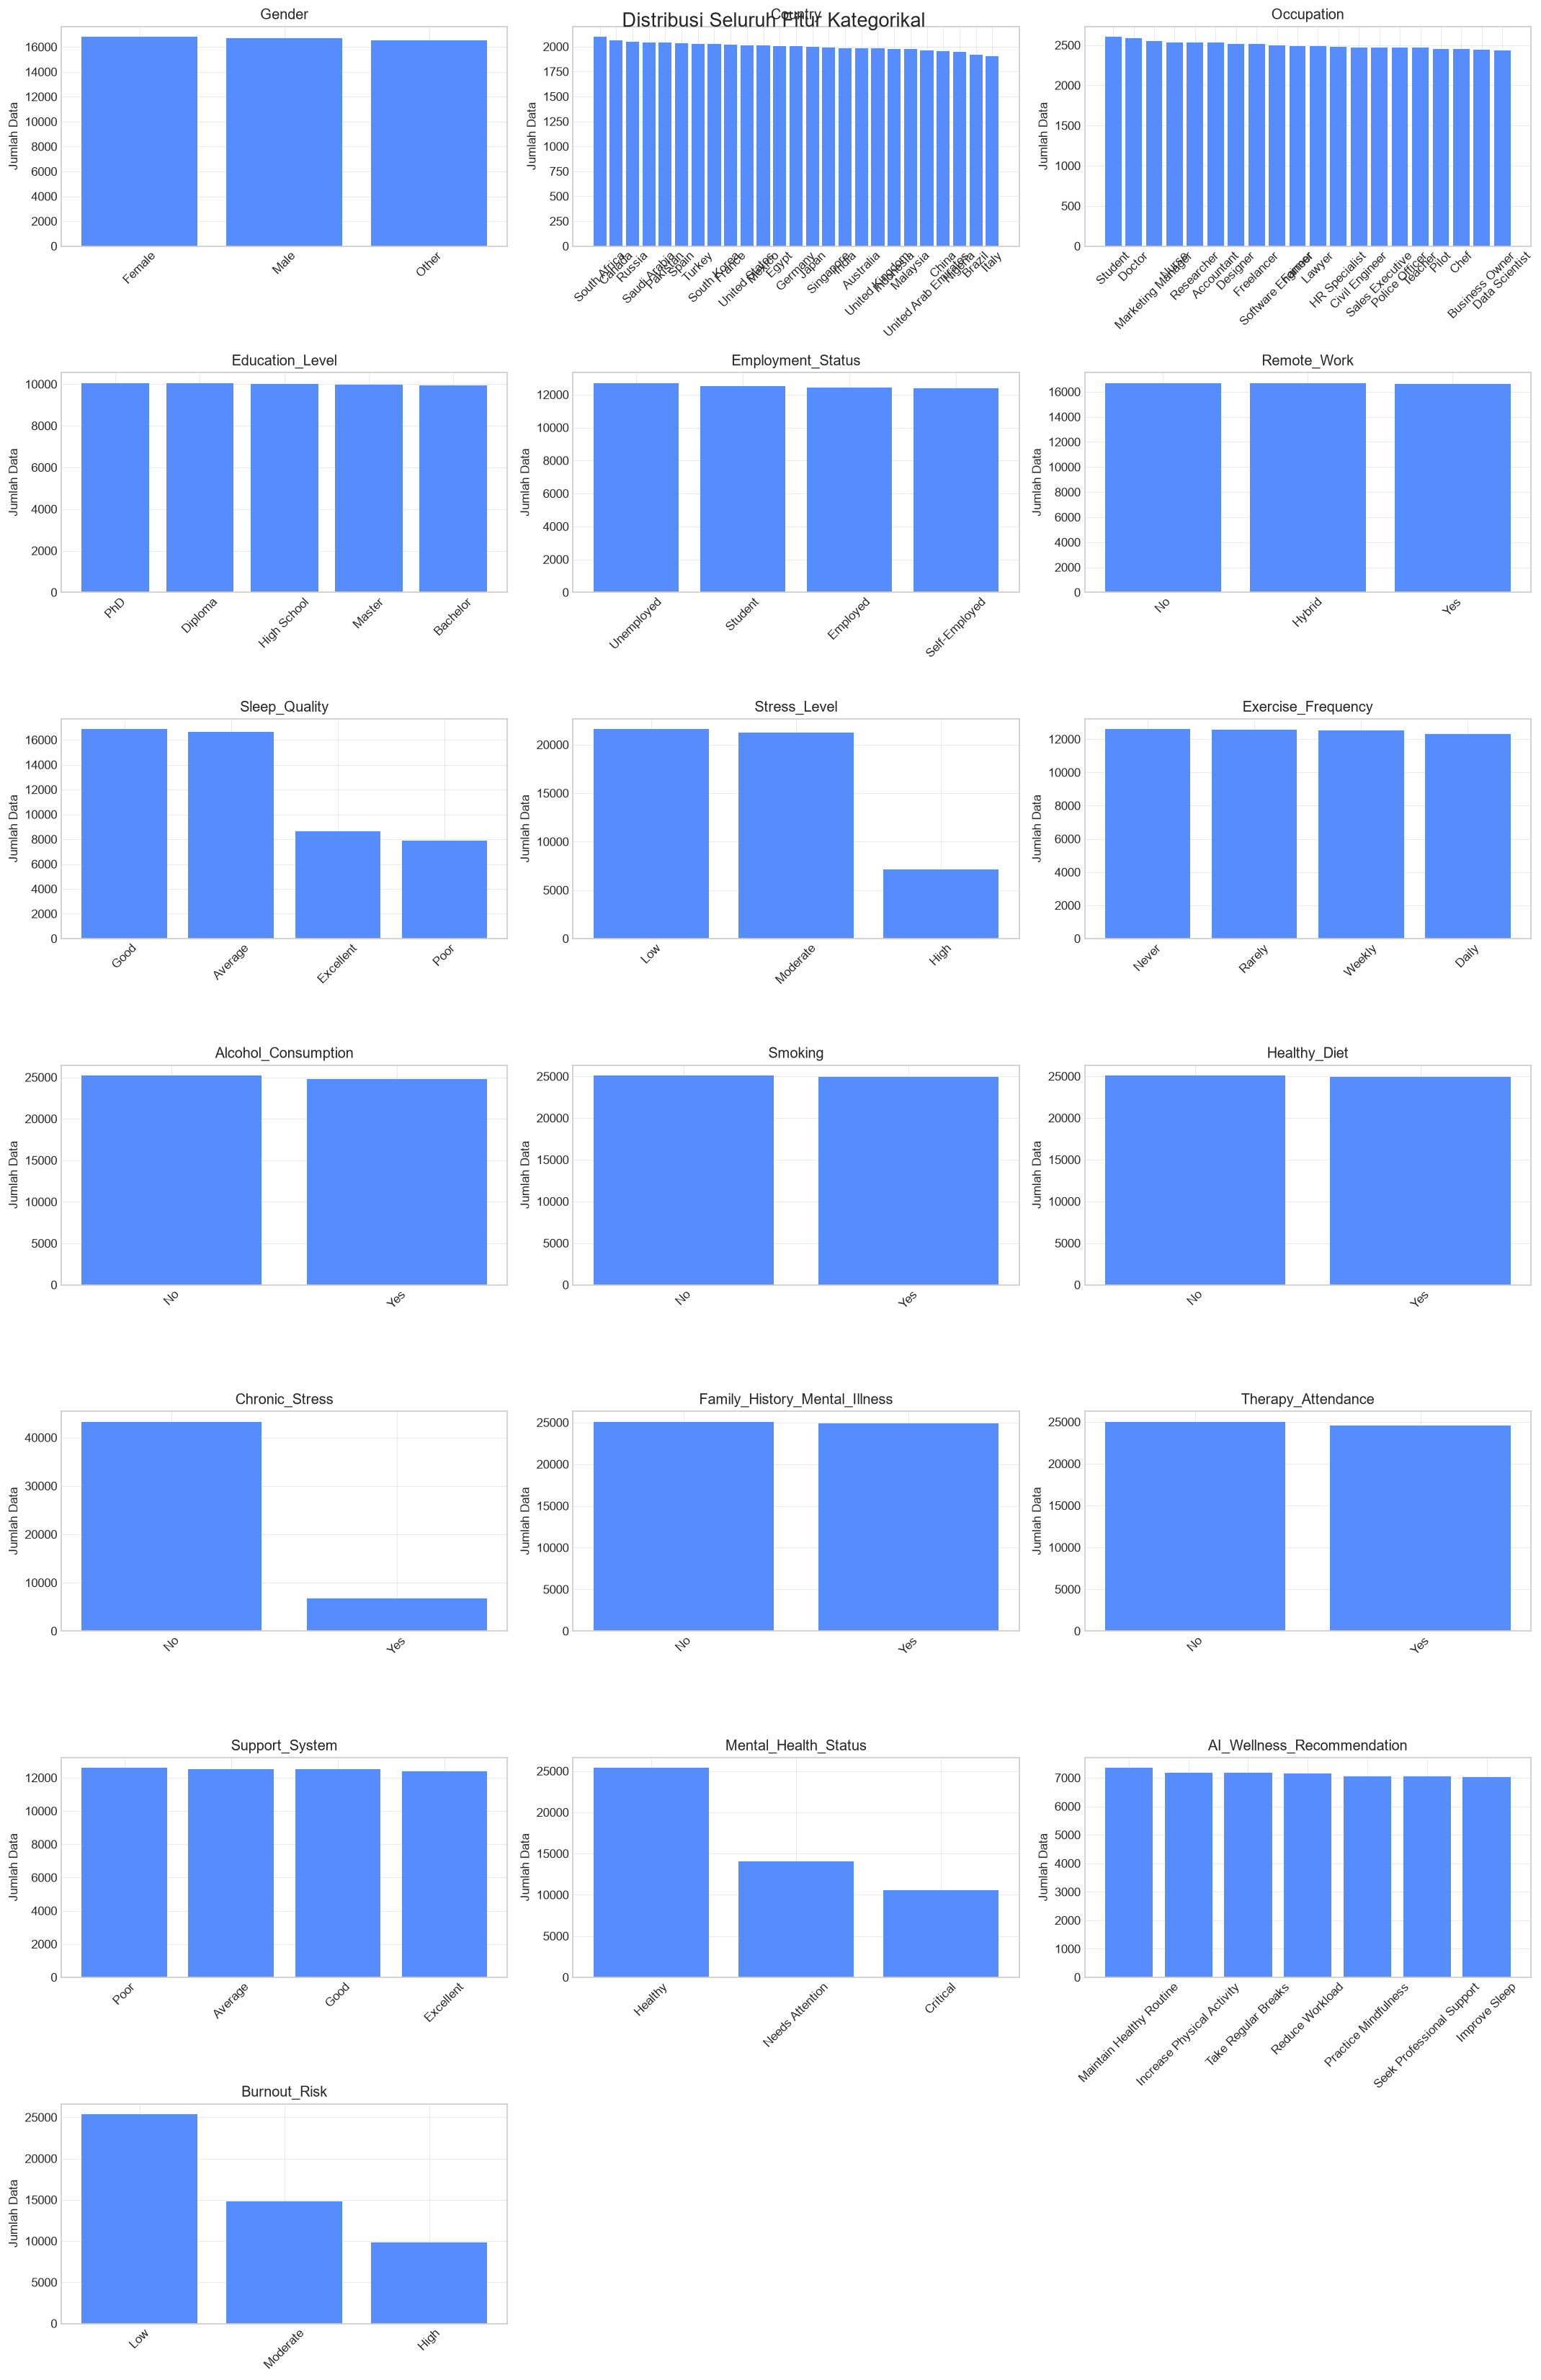

In [36]:
# FITUR NUMERIK
numeric_columns = df.select_dtypes(
    include='number'
).columns

numeric_columns = numeric_columns.drop(
    ['Person_ID'],
    errors='ignore'
)

n_features = len(numeric_columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(numeric_columns):

    axes[i].hist(
        df[column].dropna(),
        bins=20
    )

    axes[i].set_title(column)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(
    'Distribusi Seluruh Fitur Numerik',
    fontsize=16
)

plt.tight_layout()
plt.show()


# FITUR KATEGORIKAL
n_features = len(categorical_columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, column in enumerate(categorical_columns):

    counts = df[column].value_counts()

    axes[i].bar(
        counts.index.astype(str),
        counts.values
    )

    axes[i].set_title(column)
    axes[i].set_ylabel('Jumlah Data')
    axes[i].tick_params(
        axis='x',
        rotation=45
    )

for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(
    'Distribusi Seluruh Fitur Kategorikal',
    fontsize=16
)

plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [37]:
numeric_data = df[numeric_columns]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [38]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0
Emotional_Stability,0,0.0


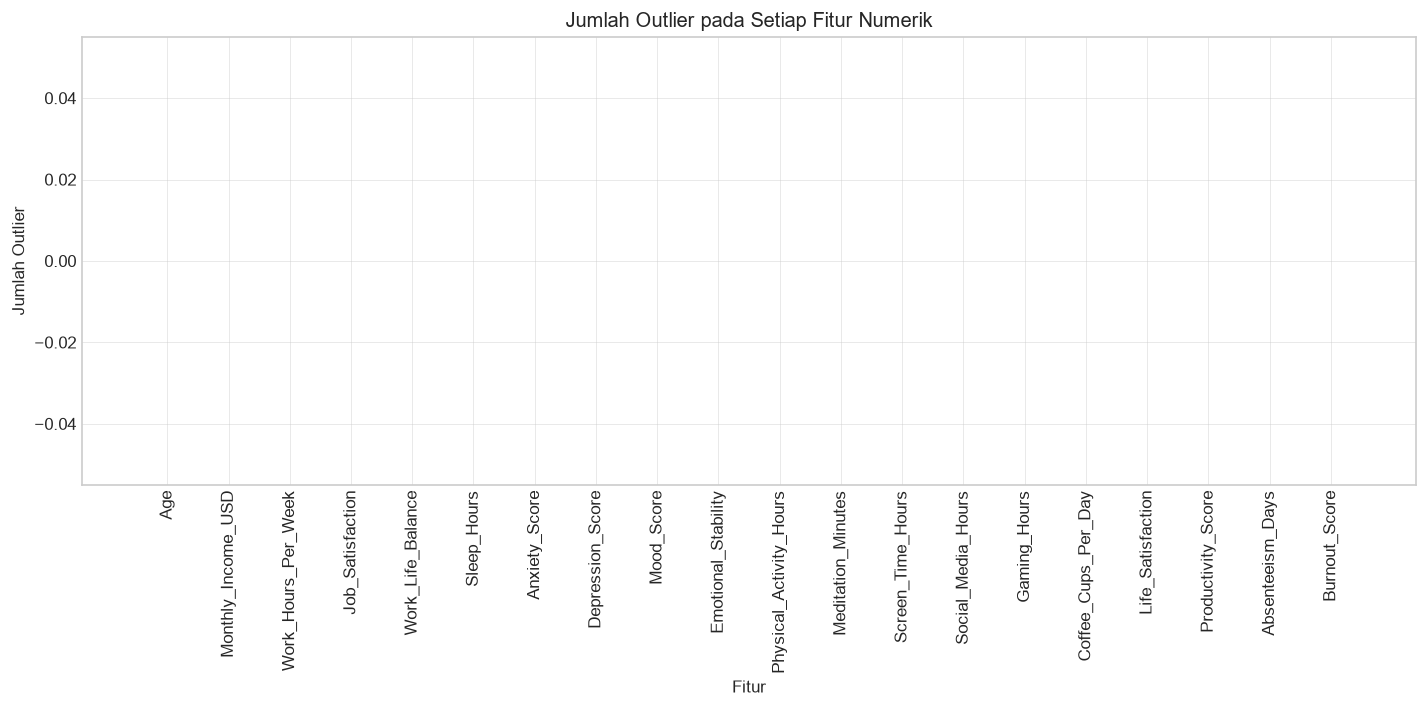

In [39]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [40]:
print(outlier_summary)

                         Jumlah Outlier  Persentase (%)
Age                                   0             0.0
Monthly_Income_USD                    0             0.0
Work_Hours_Per_Week                   0             0.0
Job_Satisfaction                      0             0.0
Work_Life_Balance                     0             0.0
Sleep_Hours                           0             0.0
Anxiety_Score                         0             0.0
Depression_Score                      0             0.0
Mood_Score                            0             0.0
Emotional_Stability                   0             0.0
Physical_Activity_Hours               0             0.0
Meditation_Minutes                    0             0.0
Screen_Time_Hours                     0             0.0
Social_Media_Hours                    0             0.0
Gaming_Hours                          0             0.0
Coffee_Cups_Per_Day                   0             0.0
Life_Satisfaction                     0         

2.1 Seleksi Kolom

In [41]:
# Drop beberapa kolom yang tidak perlu
numeric_columns = numeric_columns.drop(
    ['Burnout_Score'],
    errors='ignore'
)

categorical_columns = categorical_columns.drop(
    ['Gender', 'Country', 'Occupation', 'AI_Wellness_Recommendation', 'Burnout_Risk', 'Education_Level', 'Employment_Status'],
    errors='ignore'
)

# Menggabungkan
selected_columns = list(numeric_columns) + list(categorical_columns)

X = df[selected_columns].copy()

X.head()

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,18,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,37,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,48,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,80,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,76,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [42]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 1,
        'Yes': 0
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 1,
        'Yes': 0
    },

    'Support_System': {
        'Poor': 3,
        'Average': 2,
        'Good': 1,
        'Excellent': 0
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():
    X[column] = X[column].map(mapping)

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,1,1,0,0.0,2,2
1,1,3,1,1,1,1,0,0,1,1.0,1,2
2,0,2,1,0,1,0,1,0,1,1.0,2,1
3,2,1,0,1,1,0,1,0,0,0.0,1,0
4,0,0,0,3,1,0,1,0,1,1.0,3,0


2.3 Penanganan Missing Values

In [43]:
print('Missing value sebelum preprocessing:')
print(X.isnull().sum())

X = X.fillna(X.mean())

print('\nJumlah missing value setelah preprocessing:',)
print(X.isnull().sum())

Missing value sebelum preprocessing:
Age                               250
Monthly_Income_USD               1450
Work_Hours_Per_Week                 0
Job_Satisfaction                  500
Work_Life_Balance                 650
Sleep_Hours                       950
Anxiety_Score                     800
Depression_Score                  850
Mood_Score                        900
Emotional_Stability                 0
Physical_Activity_Hours          1100
Meditation_Minutes               1200
Screen_Time_Hours                 850
Social_Media_Hours                600
Gaming_Hours                      750
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 700
Productivity_Score                950
Absenteeism_Days                    0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking                             0
Healthy_Diet 

2.4 Penanganan Outlier

In [44]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [45]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196220,-1.059350,1.497320,-0.876176,0.525001,-1.400175,1.300669,1.318767,-1.315962,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,0.996685,2.53389,-0.996765,-1.012603,0.441976,1.633584
1,-1.261001,0.542844,-0.064238,-0.174969,0.876030,-1.341772,0.680397,1.510455,-1.198546,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,-1.003326,-0.39465,1.003245,0.995518,-0.452894,1.633584
2,1.268491,-0.939820,1.022063,0.876842,0.525001,-0.407328,0.525329,0.552016,-0.611465,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,0.441976,0.373764
3,1.702118,-0.659795,-1.354221,-1.226780,1.227060,0.059895,-1.102883,-1.134836,1.110641,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,0.996685,-0.39465,-0.996765,-1.012603,-0.452894,-0.886057
4,1.629847,0.000000,0.478912,-1.577384,-0.528088,1.227951,-0.598913,0.283653,0.288727,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,1.336847,-0.886057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.393747,-0.828849,-0.132132,0.876842,0.173971,0.001492,0.641630,0.321991,-0.572326,-0.551235,...,0.411952,-0.455507,1.008436,-0.996327,-1.003326,-0.39465,1.003245,0.995518,0.441976,0.373764
49996,1.123948,1.338592,-1.422115,-1.226780,0.173971,-1.575383,-1.335485,-1.556549,1.306335,1.556797,...,-1.014673,-1.351150,1.008436,1.003687,0.996685,-0.39465,-0.996765,-1.012603,-1.347764,-0.886057
49997,-0.538289,-0.950214,0.750488,0.876842,-1.230147,0.351909,0.951766,1.433780,-1.041991,-1.011169,...,0.411952,1.335781,1.008436,-0.996327,-1.003326,-0.39465,-0.996765,-1.012603,1.336847,1.633584
49998,1.413033,-0.755175,-1.082646,-0.174969,0.525001,0.001492,-0.327544,-0.904811,0.562698,0.100338,...,-1.014673,1.335781,1.008436,1.003687,0.996685,-0.39465,-0.996765,-1.012603,1.336847,-0.886057


2.6 Data Bersih

In [46]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (50000, 31)
Jumlah missing value: 0


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196220,-1.059350,1.497320,-0.876176,0.525001,-1.400175,1.300669,1.318767,-1.315962,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,0.996685,2.53389,-0.996765,-1.012603,0.441976,1.633584
1,-1.261001,0.542844,-0.064238,-0.174969,0.876030,-1.341772,0.680397,1.510455,-1.198546,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,-1.003326,-0.39465,1.003245,0.995518,-0.452894,1.633584
2,1.268491,-0.939820,1.022063,0.876842,0.525001,-0.407328,0.525329,0.552016,-0.611465,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,0.441976,0.373764
3,1.702118,-0.659795,-1.354221,-1.226780,1.227060,0.059895,-1.102883,-1.134836,1.110641,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,0.996685,-0.39465,-0.996765,-1.012603,-0.452894,-0.886057
4,1.629847,0.000000,0.478912,-1.577384,-0.528088,1.227951,-0.598913,0.283653,0.288727,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,0.996685,-0.39465,1.003245,0.995518,1.336847,-0.886057


3. Modeling

3.1 Penentuan Jumlah Klaster dengan Elbow Method

In [47]:
X_np = X_scaled.to_numpy()

k_values = list(range(1, 11))
manhattan_cost = []

max_iter = 300
tol = 1e-4

for k in k_values:

    rng = np.random.RandomState(42)

    initial_indices = rng.choice(
        len(X_np),
        size=k,
        replace=False
    )

    centers_test = X_np[
        initial_indices
    ].copy()

    for iteration in range(max_iter):

        distances_test = cdist(
            X_np,
            centers_test,
            metric='cityblock'
        )

        labels_test = np.argmin(
            distances_test,
            axis=1
        )

        new_centers_test = (
            centers_test.copy()
        )

        for cluster_id in range(k):

            cluster_points = X_np[
                labels_test == cluster_id
            ]

            if len(cluster_points) > 0:

                new_centers_test[
                    cluster_id
                ] = np.median(
                    cluster_points,
                    axis=0
                )

        shift = np.max(
            np.abs(
                new_centers_test
                - centers_test
            )
        )

        centers_test = (
            new_centers_test
        )

        if shift < tol:
            break

    final_distances = cdist(
        X_np,
        centers_test,
        metric='cityblock'
    )

    cost = np.sum(
        np.min(
            final_distances,
            axis=1
        )
    )

    manhattan_cost.append(cost)

In [48]:
p1 = np.array([k_values[0], manhattan_cost[0]])

p2 = np.array([k_values[-1], manhattan_cost[-1]])

line_vec = p2 - p1
line_unit = (line_vec/ np.linalg.norm(line_vec))

distances = []

for k, cost in zip(k_values,manhattan_cost):

    point = np.array([
        k,
        cost
    ])

    vec = point - p1

    projection = (
        np.dot(vec, line_unit)
        * line_unit
    )

    perpendicular = (
        vec - projection
    )

    distances.append(
        np.linalg.norm(
            perpendicular
        )
    )

n_clusters = k_values[
    np.argmax(distances)
]

print(
    f'Jumlah Cluster Optimal: '
    f'k = {n_clusters}'
)

Jumlah Cluster Optimal: k = 4


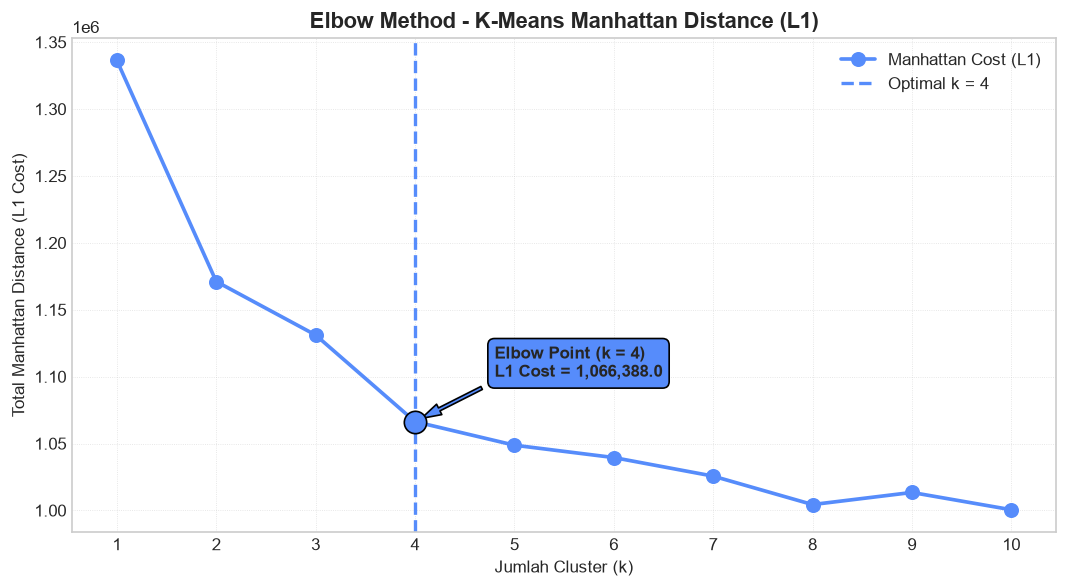

In [49]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    manhattan_cost,
    marker='o',
    markersize=8,
    linewidth=2.2,
    label='Manhattan Cost (L1)'
)

plt.axvline(
    x=n_clusters,
    linestyle='--',
    linewidth=2,
    label=f'Optimal k = {n_clusters}'
)

plt.scatter(
    [n_clusters],
    [manhattan_cost[n_clusters - 1]],
    s=180,
    zorder=5,
    edgecolor='black'
)

plt.title(
    'Elbow Method - K-Means Manhattan Distance (L1)',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel(
    'Total Manhattan Distance (L1 Cost)'
)

plt.xticks(k_values)

plt.annotate(
    f'Elbow Point (k = {n_clusters})\n'
    f'L1 Cost = '
    f'{manhattan_cost[n_clusters - 1]:,.1f}',
    xy=(
        n_clusters,
        manhattan_cost[
            n_clusters - 1
        ]
    ),
    xytext=(
        n_clusters + 0.8,
        manhattan_cost[
            n_clusters - 1
        ]
        + (
            max(manhattan_cost)
            - min(manhattan_cost)
        ) * 0.1
    ),
    arrowprops=dict(
        shrink=0.08,
        width=2,
        headwidth=7
    ),
    bbox=dict(
        boxstyle='round,pad=0.4'
    ),
    fontweight='bold'
)

plt.grid(
    True,
    linestyle=':',
    alpha=0.6
)

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'elbow_manhattan.png'
    ),
    dpi=300
)

plt.show()

3.2 Training K-Means Manhattan

In [50]:
tracemalloc.start()

start_time = time.perf_counter()

X_np = X_scaled.to_numpy()

max_iter = 300
tol = 1e-4

rng = np.random.RandomState(42)

initial_indices = rng.choice(
    len(X_np),
    size=n_clusters,
    replace=False
)

centroids = X_np[
    initial_indices
].copy()

for iteration in range(1, max_iter + 1):

    distances = cdist(X_np, centroids, metric='cityblock')

    labels = np.argmin(distances, axis=1)

    new_centroids = (centroids.copy())

    for cluster_id in range(n_clusters):

        cluster_points = X_np[labels == cluster_id]

        if len(cluster_points) > 0:

            new_centroids[cluster_id] = np.median(cluster_points,axis=0)

    shift = np.max(
        np.abs(
            new_centroids
            - centroids
        )
    )

    centroids = new_centroids

    if shift < tol:
        break

In [51]:
distances = cdist(
    X_np,
    centroids,
    metric='cityblock'
)

labels = np.argmin(
    distances,
    axis=1
)

manhattan_objective = np.sum(
    np.min(
        distances,
        axis=1
    )
)

runtime = (
    time.perf_counter()
    - start_time
)

current_memory, peak_memory = (
    tracemalloc.get_traced_memory()
)

tracemalloc.stop()

peak_memory_mb = (
    peak_memory
    / (1024 ** 2)
)

iterations = iteration

df['KMeans_Cluster'] = labels

In [52]:
print(
    f'Runtime     : '
    f'{runtime:.5f} detik'
)

print(
    f'Iterations  : '
    f'{iterations}'
)

print(
    f'L1 Cost     : '
    f'{manhattan_objective:.2f}'
)

print(
    f'Peak Memory : '
    f'{peak_memory_mb:.2f} MB'
)

Runtime     : 1.94458 detik
Iterations  : 21
L1 Cost     : 1066388.04
Peak Memory : 10.64 MB


4. Evaluasi

4.1 Silhouette Score

In [53]:
silhouette = float(
    silhouette_score(
        X_scaled,
        labels,
        metric='manhattan'
    )
)

print(
    f'Silhouette Score: '
    f'{silhouette:.4f}'
)

Silhouette Score: 0.0912


4.2 Davies-Bouldin Index

In [54]:
db_index = float(
    davies_bouldin_score(
        X_scaled,
        labels
    )
)

print(f'Davies-Bouldin Index: ' f'{db_index:.4f}')

Davies-Bouldin Index: 3.9385


4.3 Calinski-Harabasz Index

In [55]:
ch_index = float(
    calinski_harabasz_score(
        X_scaled,
        labels
    )
)

print(f'Calinski-Harabasz Index: ' f'{ch_index:.2f}')

Calinski-Harabasz Index: 4992.48


4.4 Distribusi Cluster

In [56]:
cluster_distribution = (
    df['KMeans_Cluster']
    .value_counts()
    .sort_index()
)

cluster_distribution

KMeans_Cluster
0    12401
1    12484
2    17163
3     7952
Name: count, dtype: int64

4.5 Ringkasan Evaluasi

In [57]:
model_summary = pd.DataFrame([{
    'Model':
        'K-Means Manhattan',

    'Distance Metric':
        'Manhattan Distance (L1)',

    'Jumlah Cluster':
        n_clusters,

    'Silhouette Score (↑)':
        round(silhouette, 4),

    'Davies-Bouldin Index (↓)':
        round(db_index, 4),

    'Calinski-Harabasz Index (↑)':
        round(ch_index, 2),

    'Execution Time (s) (↓)':
        round(runtime, 5),

    'Iterations (↓)':
        iterations,

    'Objective Value (L1) (↓)':
        round(
            manhattan_objective,
            2
        ),

    'Alokasi Memori (MB)':
        round(
            peak_memory_mb,
            2
        )
}])

model_summary

,Model,Distance Metric,Jumlah Cluster,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations (↓),Objective Value (L1) (↓),Alokasi Memori (MB)
0,K-Means Manhattan,Manhattan Distance (L1),4,0.0912,3.9385,4992.48,1.94458,21,1066388.04,10.64


4.6 Export Hasil

In [58]:
excel_path = os.path.join(
    OUTPUT_DIR,
    'evaluasi_kmeans_manhattan.xlsx'
)

df_clustered = df.copy()

df_clustered[
    'KMeans_Cluster'
] = labels

with pd.ExcelWriter(
    excel_path,
    engine='openpyxl'
) as writer:

    model_summary.to_excel(
        writer,
        sheet_name='Ringkasan_Evaluasi',
        index=False
    )

    df_clustered.to_excel(
        writer,
        sheet_name='Data_Terklaster',
        index=False
    )

print(
    f'Hasil disimpan ke: {excel_path}'
)

Hasil disimpan ke: outputKmeansManhattan\evaluasi_kmeans_manhattan.xlsx


5. Reduksi Dimensi PCA

5.1 PCA

In [59]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

centroids_pca = pca.transform(centroids)

5.2 Visualisasi Hasil Klaster

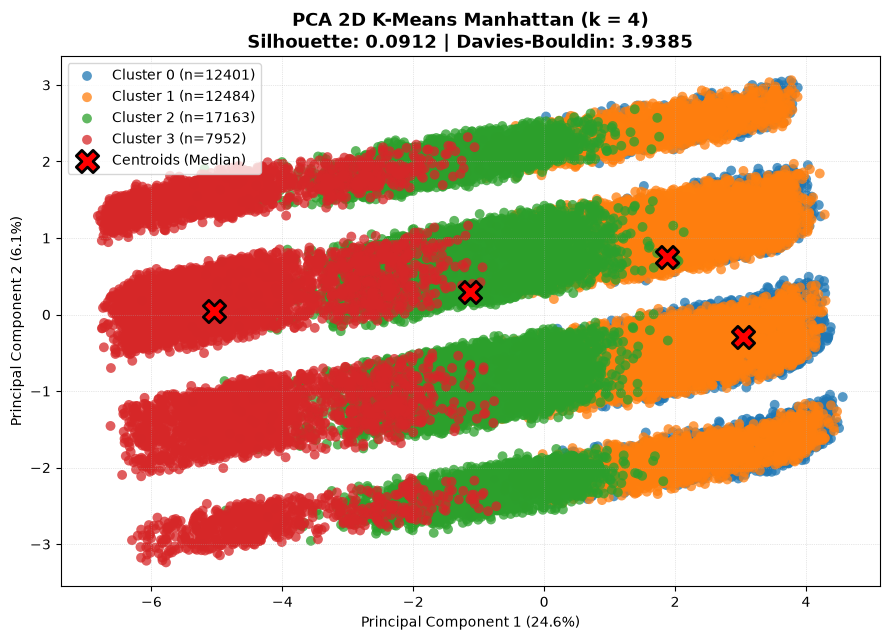

In [60]:
plt.figure(figsize=(9, 6.5))

palette = sns.color_palette('tab10', n_clusters)

for k in range(n_clusters):

    mask = labels == k

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=palette[k],
        label=(
            f'Cluster {k} '
            f'(n={np.sum(mask)})'
        ),
        alpha=0.75,
        s=50,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    s=260,
    c='red',
    edgecolor='black',
    linewidth=2,
    label='Centroids (Median)',
    zorder=10
)

plt.title(
    f'PCA 2D K-Means Manhattan '
    f'(k = {n_clusters})\n'
    f'Silhouette: {silhouette:.4f} | '
    f'Davies-Bouldin: {db_index:.4f}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Principal Component 1 ' f'({pca.explained_variance_ratio_[0] * 100:.1f}%)')

plt.ylabel('Principal Component 2 ' f'({pca.explained_variance_ratio_[1] * 100:.1f}%)')

plt.grid(True, linestyle=':', alpha=0.6)

plt.legend(frameon=True, loc='best')

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'cluster_manhattan.png'
    ),
    dpi=300
)

plt.show()

6. Analisis

6.1 Profil Cluster

In [61]:
df_analysis = X.copy()

df_analysis['KMeans_Cluster'] = labels

cluster_profile = (
    df_analysis
    .groupby('KMeans_Cluster')
    .median()
)

cluster_profile

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,,
0,42.000000,6251.281524,33.0,6.0,6.0,8.0,12.0,13.0,87.0,87.0,...,0.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0
1,41.000000,6251.281524,36.0,5.0,6.0,6.8,26.0,26.0,74.0,74.0,...,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,41.448181,6251.281524,51.0,5.0,5.0,6.8,52.0,52.0,48.0,48.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,1.0
3,41.000000,6251.281524,61.0,6.0,6.0,6.1,80.0,80.0,21.0,20.0,...,2.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0


6.2 Perbandingan Cluster dengan Burnout Risk

In [62]:
comparison = pd.crosstab(
    df['KMeans_Cluster'],
    df['Burnout_Risk']
)

comparison

comparison_percentage = pd.crosstab(
    df['KMeans_Cluster'],
    df['Burnout_Risk'],
    normalize='index'
) * 100

comparison_percentage.round(2)

Burnout_Risk,High,Low,Moderate
KMeans_Cluster,,,
0,0.00,96.16,3.84
1,0.10,86.61,13.28
2,16.77,15.32,67.91
3,87.53,0.01,12.46


6.3 Analisis Centroid

In [63]:
centroid_original = (
    scaler.inverse_transform(
        centroids
    )
)

centroid_original = pd.DataFrame(
    centroid_original,
    columns=X.columns
)

centroid_original.index.name = (
    'Cluster'
)

centroid_original

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
Cluster,,,,,,,,,,,,,,,,,,,,,
0,42.000000,6251.281524,33.0,6.0,6.0,8.0,12.0,13.0,87.0,87.0,...,0.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0
1,41.000000,6251.281524,36.0,5.0,6.0,6.8,26.0,26.0,74.0,74.0,...,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,41.448181,6251.281524,51.0,5.0,5.0,6.8,52.0,52.0,48.0,48.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,1.0
3,41.000000,6251.281524,61.0,6.0,6.0,6.1,80.0,80.0,21.0,20.0,...,2.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0
